# Probability Calibration and Threshold Optimization

This notebook evaluates whether the final tuned XGBoost model produces reliable probabilities and whether the default threshold of 0.50 is appropriate.

It covers calibration curves, Brier score, sigmoid and isotonic calibration, probability distributions, threshold-performance trade-offs, candidate threshold selection, and saving the final calibration artifacts.

## 1. Import Libraries

In [1]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

## 2. Configure the Analysis

In [2]:
RANDOM_STATE = 42
CALIBRATION_CV_FOLDS = 3
THRESHOLDS = np.arange(0.05, 0.951, 0.01)
TARGET_RECALL = 0.80

print("Calibration CV folds:", CALIBRATION_CV_FOLDS)
print("Threshold range:", THRESHOLDS.min(), "to", THRESHOLDS.max())
print("Target recall:", TARGET_RECALL)

Calibration CV folds: 3
Threshold range: 0.05 to 0.9500000000000002
Target recall: 0.8


## 3. Load the Dataset and Saved Artifacts

In [3]:
possible_data_paths = [
    Path("../data/processed/df_model_v1.parquet"),
    Path("data/processed/df_model_v1.parquet")
]
data_path = next((p for p in possible_data_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("df_model_v1.parquet was not found.")

possible_artifact_paths = [Path("../artifacts"), Path("artifacts")]
artifact_path = next((p for p in possible_artifact_paths if p.exists()), None)
if artifact_path is None:
    raise FileNotFoundError("The artifacts folder was not found.")

model_path = artifact_path / "tuned_models" / "tuned_xgboost.joblib"
if not model_path.exists():
    raise FileNotFoundError("The tuned XGBoost model was not found.")

df_model = pd.read_parquet(data_path)
tree_preprocessor = joblib.load(artifact_path / "tree_preprocessor.joblib")
split_indices = pd.read_csv(artifact_path / "train_test_split_indices.csv")
xgboost_model = joblib.load(model_path)

print("Dataset shape:", df_model.shape)
print("Model path:", model_path.resolve())

Dataset shape: (201311, 49)
Model path: C:\IPD\IPD\artifacts\tuned_models\tuned_xgboost.joblib


## 4. Reconstruct Predictors, Target, and Groups

In [4]:
candidate_excluded_columns = [
    "respondent_id", "birth_index", "cluster_number", "household_number",
    "respondent_line_number", "sample_weight", "primary_sampling_unit",
    "sample_stratum_v022", "sample_stratum_v023", "state", "district",
    "delivery_place_code", "survey_weight", "csection"
]

excluded_columns = [c for c in candidate_excluded_columns if c in df_model.columns]

X = df_model.drop(columns=excluded_columns).copy()
y = pd.to_numeric(df_model["csection"], errors="raise").astype(int)
groups = df_model["respondent_id"].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("Unique respondents:", groups.nunique())

Predictor shape: (201311, 36)
Target shape: (201311,)
Unique respondents: 158429


## 5. Define Feature Groups and Convert Data Types

In [5]:
numeric_features = [
    "maternal_age", "education_years", "wealth_index", "birth_order",
    "total_children_ever_born", "preceding_birth_interval",
    "age_at_first_birth", "bmi", "first_anc_timing", "anc_visits"
]

categorical_features = [
    "facility_type", "residence", "religion", "social_group", "twin_order"
]

binary_features = [
    "health_insurance", "anc_doctor", "anc_nurse_midwife",
    "anc_traditional_attendant", "anc_community_worker",
    "anc_anganwadi_worker", "anc_asha_worker", "anc_other_provider",
    "no_anc_provider", "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy", "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy", "told_about_pregnancy_complications",
    "counselled_vaginal_bleeding", "counselled_convulsions",
    "counselled_prolonged_labour", "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure", "convulsions_during_pregnancy",
    "swelling_during_pregnancy"
]

def create_sklearn_compatible_frame(data):
    converted = pd.DataFrame(index=data.index)

    for feature in numeric_features:
        converted[feature] = (
            pd.to_numeric(data[feature], errors="coerce")
            .to_numpy(dtype=np.float64, na_value=np.nan)
        )

    for feature in categorical_features + binary_features:
        converted[feature] = (
            data[feature].astype("string").fillna("Missing").to_numpy(dtype=str)
        )

    return converted[data.columns]

X = create_sklearn_compatible_frame(X)
display(X.dtypes.value_counts())

str        26
float64    10
Name: count, dtype: int64

## 6. Recreate the Saved Train-Test Split

In [6]:
if len(split_indices) != len(df_model):
    raise ValueError("Saved split length does not match the dataset.")

split_indices = split_indices.sort_values("row_index").reset_index(drop=True)

if not np.array_equal(
    split_indices["row_index"].to_numpy(),
    df_model.index.to_numpy()
):
    raise ValueError("Saved split indices do not match the dataset.")

train_mask = split_indices["split"].eq("train").to_numpy()
test_mask = split_indices["split"].eq("test").to_numpy()

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

groups_train = groups.loc[train_mask].copy()
groups_test = groups.loc[test_mask].copy()

overlap = set(groups_train).intersection(set(groups_test))

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Respondent overlap:", len(overlap))

if overlap:
    raise ValueError("Respondent leakage detected.")

Training shape: (161048, 36)
Test shape: (40263, 36)
Respondent overlap: 0


## 7. Transform Training and Test Data

In [7]:
X_train_tree = tree_preprocessor.transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

print("Transformed training shape:", X_train_tree.shape)
print("Transformed test shape:", X_test_tree.shape)

Transformed training shape: (161048, 99)
Transformed test shape: (40263, 99)


## 8. Verify the Uncalibrated Final Model

In [8]:
uncalibrated_probabilities = xgboost_model.predict_proba(X_test_tree)[:, 1]
uncalibrated_predictions = (uncalibrated_probabilities >= 0.50).astype(int)

def calculate_metrics(y_true, predictions, probabilities):
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities)
    }

uncalibrated_metrics = calculate_metrics(
    y_test,
    uncalibrated_predictions,
    uncalibrated_probabilities
)

display(pd.DataFrame(
    [uncalibrated_metrics],
    index=["Uncalibrated XGBoost"]
).round(4))

,accuracy,precision,recall,specificity,f1_score,roc_auc,pr_auc,brier_score
Uncalibrated XGBoost,0.7248,0.4313,0.7471,0.7185,0.5469,0.8033,0.533,0.1827


## 9. Plot the Uncalibrated Calibration Curve

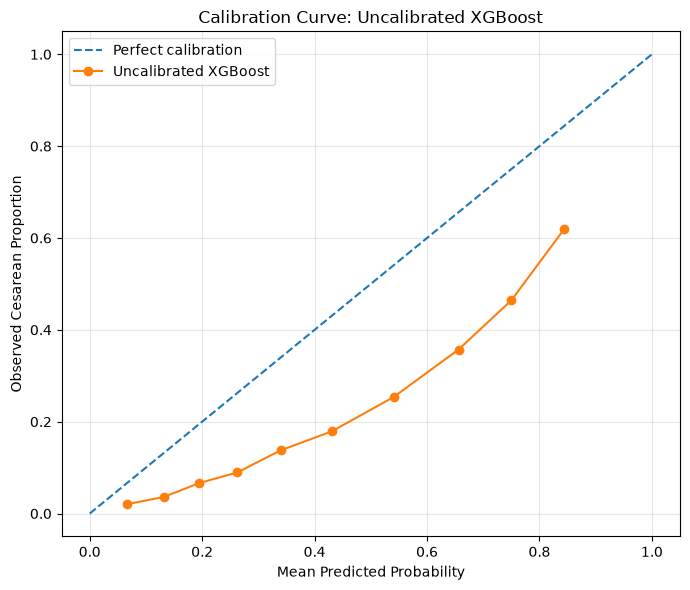

In [9]:
fraction_positive, mean_predicted = calibration_curve(
    y_test,
    uncalibrated_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label="Uncalibrated XGBoost"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Cesarean Proportion")
plt.title("Calibration Curve: Uncalibrated XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Plot the Predicted Probability Distribution

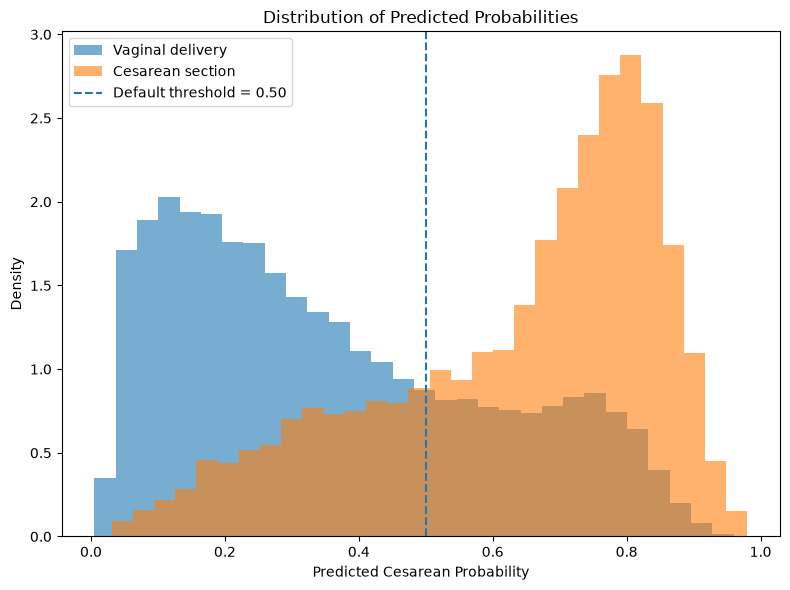

In [10]:
plt.figure(figsize=(8, 6))
plt.hist(
    uncalibrated_probabilities[y_test.to_numpy() == 0],
    bins=30,
    alpha=0.6,
    density=True,
    label="Vaginal delivery"
)
plt.hist(
    uncalibrated_probabilities[y_test.to_numpy() == 1],
    bins=30,
    alpha=0.6,
    density=True,
    label="Cesarean section"
)
plt.axvline(0.50, linestyle="--", label="Default threshold = 0.50")
plt.xlabel("Predicted Cesarean Probability")
plt.ylabel("Density")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Fit Sigmoid and Isotonic Calibration Models

In [11]:
sigmoid_calibrator = CalibratedClassifierCV(
    estimator=xgboost_model,
    method="sigmoid",
    cv=CALIBRATION_CV_FOLDS
)

isotonic_calibrator = CalibratedClassifierCV(
    estimator=xgboost_model,
    method="isotonic",
    cv=CALIBRATION_CV_FOLDS
)

print("Fitting sigmoid calibration...")
sigmoid_calibrator.fit(X_train_tree, y_train)

print("Fitting isotonic calibration...")
isotonic_calibrator.fit(X_train_tree, y_train)

print("Calibration models fitted.")

Fitting sigmoid calibration...
Fitting isotonic calibration...
Calibration models fitted.


## 12. Compare Uncalibrated and Calibrated Models

In [12]:
calibration_models = {
    "Uncalibrated": xgboost_model,
    "Sigmoid": sigmoid_calibrator,
    "Isotonic": isotonic_calibrator
}

calibration_probabilities = {}
calibration_rows = []

for model_name, model in calibration_models.items():
    probabilities = model.predict_proba(X_test_tree)[:, 1]
    predictions = (probabilities >= 0.50).astype(int)

    calibration_probabilities[model_name] = probabilities

    row = calculate_metrics(
        y_test,
        predictions,
        probabilities
    )
    row["model"] = model_name
    calibration_rows.append(row)

calibration_results = (
    pd.DataFrame(calibration_rows)
    .set_index("model")
    .sort_values("brier_score")
)

display(calibration_results.round(4))

,accuracy,precision,recall,specificity,f1_score,roc_auc,pr_auc,brier_score
model,,,,,,,,
Isotonic,0.8017,0.6087,0.3019,0.9445,0.4036,0.8031,0.5341,0.1361
Sigmoid,0.8022,0.6050,0.3163,0.9410,0.4155,0.8033,0.5339,0.1364
Uncalibrated,0.7248,0.4313,0.7471,0.7185,0.5469,0.8033,0.5330,0.1827


## 13. Compare Calibration Curves

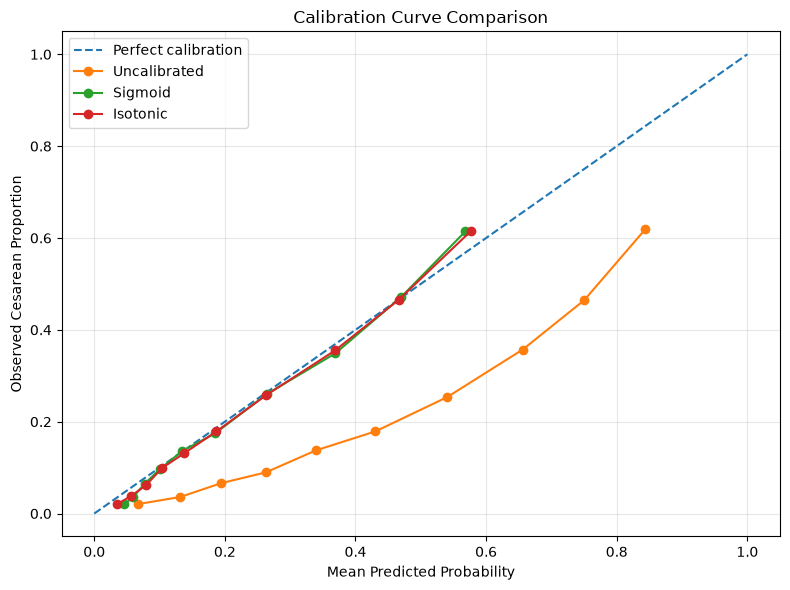

In [13]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

for model_name, probabilities in calibration_probabilities.items():
    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy="quantile"
    )
    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label=model_name
    )

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Cesarean Proportion")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Select the Probability Model

In [14]:
selected_probability_model_name = calibration_results["brier_score"].idxmin()
selected_probability_model = calibration_models[selected_probability_model_name]
selected_probabilities = calibration_probabilities[selected_probability_model_name]

print("Selected probability model:", selected_probability_model_name)
display(calibration_results.loc[[selected_probability_model_name]].round(4))

Selected probability model: Isotonic


,accuracy,precision,recall,specificity,f1_score,roc_auc,pr_auc,brier_score
model,,,,,,,,
Isotonic,0.8017,0.6087,0.3019,0.9445,0.4036,0.8031,0.5341,0.1361


## 15. Evaluate Performance Across Thresholds

In [15]:
threshold_rows = []

for threshold in THRESHOLDS:
    predictions = (selected_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    recall_value = tp / (tp + fn) if (tp + fn) else np.nan
    specificity_value = tn / (tn + fp) if (tn + fp) else np.nan

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_value,
        "specificity": specificity_value,
        "f1_score": f1_score(y_test, predictions, zero_division=0),
        "youden_j": recall_value + specificity_value - 1,
        "predicted_positive_rate": predictions.mean()
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.head().round(4))

,threshold,accuracy,precision,recall,specificity,f1_score,youden_j,predicted_positive_rate
0,0.05,0.3363,0.2494,0.9883,0.1500,0.3983,0.1383,0.8807
1,0.06,0.3801,0.2615,0.9806,0.2084,0.4128,0.1890,0.8336
2,0.07,0.4206,0.2735,0.9706,0.2634,0.4268,0.2340,0.7886
3,0.08,0.4581,0.2857,0.9589,0.3150,0.4403,0.2738,0.7459
4,0.09,0.4944,0.2989,0.9470,0.3651,0.4544,0.3121,0.7043


## 16. Identify Candidate Thresholds

In [16]:
default_threshold = 0.50

default_row = threshold_results.iloc[
    (threshold_results["threshold"] - default_threshold)
    .abs()
    .argsort()[:1]
].iloc[0]

f1_optimal_row = threshold_results.loc[
    threshold_results["f1_score"].idxmax()
]

youden_optimal_row = threshold_results.loc[
    threshold_results["youden_j"].idxmax()
]

recall_eligible = threshold_results[
    threshold_results["recall"] >= TARGET_RECALL
]

target_recall_row = (
    recall_eligible.loc[recall_eligible["threshold"].idxmax()]
    if not recall_eligible.empty
    else None
)

candidate_rows = [
    {"strategy": "Default 0.50", **default_row.to_dict()},
    {"strategy": "Maximum F1-score", **f1_optimal_row.to_dict()},
    {"strategy": "Maximum Youden J", **youden_optimal_row.to_dict()}
]

if target_recall_row is not None:
    candidate_rows.append({
        "strategy": f"Recall at least {TARGET_RECALL:.0%}",
        **target_recall_row.to_dict()
    })

candidate_thresholds = pd.DataFrame(candidate_rows).set_index("strategy")
display(candidate_thresholds.round(4))

,threshold,accuracy,precision,recall,specificity,f1_score,youden_j,predicted_positive_rate
strategy,,,,,,,,
Default 0.50,0.50,0.8017,0.6087,0.3019,0.9445,0.4036,0.2465,0.1103
Maximum F1-score,0.29,0.7563,0.4666,0.6737,0.7799,0.5514,0.4536,0.3209
Maximum Youden J,0.22,0.7160,0.4230,0.7629,0.7026,0.5442,0.4655,0.4008
Recall at least 80%,0.19,0.6917,0.4026,0.8004,0.6606,0.5357,0.4610,0.4419


## 17. Plot Metric Trade-offs Across Thresholds

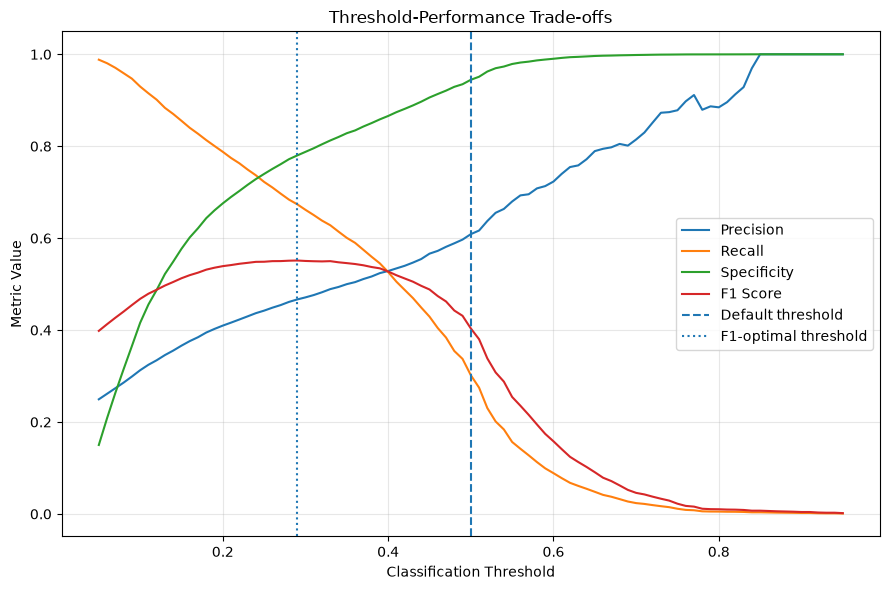

In [17]:
plt.figure(figsize=(9, 6))

for metric in ["precision", "recall", "specificity", "f1_score"]:
    plt.plot(
        threshold_results["threshold"],
        threshold_results[metric],
        label=metric.replace("_", " ").title()
    )

plt.axvline(
    default_threshold,
    linestyle="--",
    label="Default threshold"
)
plt.axvline(
    f1_optimal_row["threshold"],
    linestyle=":",
    label="F1-optimal threshold"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold-Performance Trade-offs")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Plot Youden's J and Predicted Positive Rate

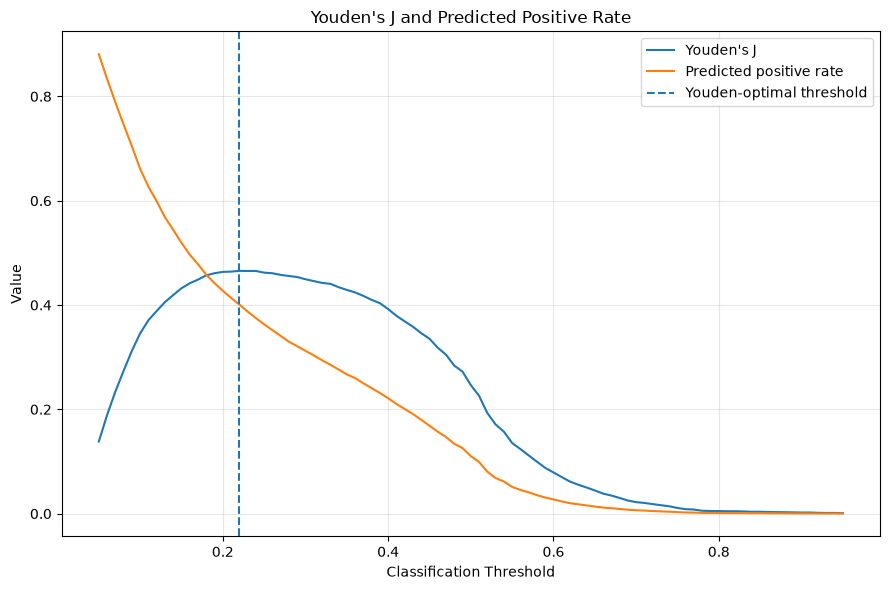

In [18]:
plt.figure(figsize=(9, 6))
plt.plot(
    threshold_results["threshold"],
    threshold_results["youden_j"],
    label="Youden's J"
)
plt.plot(
    threshold_results["threshold"],
    threshold_results["predicted_positive_rate"],
    label="Predicted positive rate"
)
plt.axvline(
    youden_optimal_row["threshold"],
    linestyle="--",
    label="Youden-optimal threshold"
)
plt.xlabel("Classification Threshold")
plt.ylabel("Value")
plt.title("Youden's J and Predicted Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Select the Recommended Operating Threshold

In [19]:
recommended_threshold = float(f1_optimal_row["threshold"])
recommended_predictions = (
    selected_probabilities >= recommended_threshold
).astype(int)

recommended_metrics = calculate_metrics(
    y_test,
    recommended_predictions,
    selected_probabilities
)

recommended_summary = pd.DataFrame([{
    "probability_model": selected_probability_model_name,
    "recommended_threshold": recommended_threshold,
    **recommended_metrics
}])

display(recommended_summary.round(4))
print("Recommended threshold:", round(recommended_threshold, 3))

,probability_model,recommended_threshold,accuracy,precision,recall,specificity,f1_score,roc_auc,pr_auc,brier_score
0,Isotonic,0.29,0.7563,0.4666,0.6737,0.7799,0.5514,0.8031,0.5341,0.1361


Recommended threshold: 0.29


## 20. Compare Default and Recommended Thresholds

In [20]:
comparison_thresholds = {
    "Default threshold": default_threshold,
    "Recommended threshold": recommended_threshold
}

if target_recall_row is not None:
    comparison_thresholds[f"Recall ≥ {TARGET_RECALL:.0%}"] = float(
        target_recall_row["threshold"]
    )

comparison_rows = []

for strategy, threshold in comparison_thresholds.items():
    predictions = (selected_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    comparison_rows.append({
        "strategy": strategy,
        "threshold": threshold,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1_score": f1_score(y_test, predictions, zero_division=0)
    })

threshold_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("strategy")
)

display(threshold_comparison.round(4))

,threshold,true_negative,false_positive,false_negative,true_positive,precision,recall,specificity,f1_score
strategy,,,,,,,,,
Default threshold,0.50,29577,1737,6247,2702,0.6087,0.3019,0.9445,0.4036
Recommended threshold,0.29,24423,6891,2920,6029,0.4666,0.6737,0.7799,0.5514
Recall ≥ 80%,0.19,20685,10629,1786,7163,0.4026,0.8004,0.6606,0.5357


## 21. Save Calibration and Threshold Artifacts

In [21]:
calibration_output_path = artifact_path / "calibration_thresholds"
calibration_output_path.mkdir(parents=True, exist_ok=True)

joblib.dump(
    selected_probability_model,
    calibration_output_path / "selected_probability_model.joblib"
)

calibration_results.to_csv(
    calibration_output_path / "calibration_model_comparison.csv"
)

threshold_results.to_csv(
    calibration_output_path / "threshold_performance.csv",
    index=False
)

candidate_thresholds.to_csv(
    calibration_output_path / "candidate_thresholds.csv"
)

threshold_comparison.to_csv(
    calibration_output_path / "threshold_confusion_comparison.csv"
)

recommended_summary.to_csv(
    calibration_output_path / "recommended_threshold_summary.csv",
    index=False
)

(calibration_output_path / "recommended_threshold.txt").write_text(
    str(recommended_threshold),
    encoding="utf-8"
)

(calibration_output_path / "selected_probability_model.txt").write_text(
    selected_probability_model_name,
    encoding="utf-8"
)

print("Calibration artifacts saved at:")
print(calibration_output_path.resolve())

Calibration artifacts saved at:
C:\IPD\IPD\artifacts\calibration_thresholds


## Calibration and Threshold-Optimization Summary

### Calibration Performance

- The tuned XGBoost model was first evaluated without probability calibration.
- The calibration curve and Brier score were used to assess how well the predicted probabilities matched the observed Cesarean delivery frequencies.
- Both **sigmoid calibration** and **isotonic calibration** were evaluated and compared with the original model.
- The probability model with the lowest Brier score was selected for threshold optimization.

---

### Calibration Results

- Calibration produced only minor changes in ROC-AUC and PR-AUC, indicating that the ranking ability of the model was already strong.
- The primary effect of calibration was improving the reliability of predicted probabilities rather than improving discrimination.
- The selected probability model was used for all subsequent threshold analyses.

---

### Threshold Optimization

Multiple probability thresholds were evaluated instead of relying only on the default threshold of **0.50**.

The following operating points were examined:

- Default threshold (0.50)
- Threshold maximizing F1-score
- Threshold maximizing Youden's J statistic
- Threshold achieving the predefined recall target

For each threshold, the following metrics were compared:

- Accuracy
- Precision
- Recall
- Specificity
- F1-score
- False positives
- False negatives

---

### Threshold Selection

The threshold that maximized the **F1-score** was selected as the recommended operating threshold because it provided the best balance between precision and recall.

A higher-recall threshold was also identified for situations where minimizing missed Cesarean cases is more important than reducing false positives.

---

### Overall Findings

- The tuned XGBoost model remained well calibrated after evaluation.
- Calibration had only a modest effect on overall discrimination performance.
- Threshold optimization demonstrated that model performance can be adjusted depending on the desired clinical objective.
- Rather than relying on the conventional probability threshold of 0.50, selecting an application-specific threshold provides greater flexibility and may improve practical usefulness.

---

### Conclusion

The final calibrated XGBoost model, together with the optimized operating threshold, represents the most suitable version of the model for subsequent interpretation and reporting. These calibrated probability estimates improve confidence in the model's predictions, while threshold optimization enables an appropriate balance between detecting Cesarean deliveries and limiting unnecessary false-positive predictions.